## 1. Imports & Configuration

In [5]:
import os
import glob
import warnings
import random
import json
import pickle
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve
    )

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("Libraries imported")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

Libraries imported
PyTorch version: 2.10.0+cpu
CUDA available: False


In [6]:
# Configuration and Hyperparameters
CONFIG = {
    # Data
    'SEQUENCE_LENGTH': 48,
    'STRIDE': 12,
    'TEST_SIZE': 0.15,
    'VAL_SIZE': 0.15,
    'MAX_PATIENTS': None,
    'LABEL_STRATEGY': 'any_positive_window',  # user-selected strategy

    # Model
    'INPUT_DIM': None,
    'TCN_CHANNELS': 64,
    'TCN_KERNEL_SIZES': [3, 5, 7],
    'TCN_DILATIONS': [1, 2, 4],
    'TRANSFORMER_DIM': 128,
    'TRANSFORMER_HEADS': 4,
    'TRANSFORMER_LAYERS': 2,
    'TRANSFORMER_FF_DIM': 256,
    'DROPOUT': 0.3,

    # Training
    'BATCH_SIZE': 256,
    'LEARNING_RATE': 1e-3,
    'WEIGHT_DECAY': 1e-4,
    'EPOCHS': 30,
    'PATIENCE': 7,
    'GRAD_CLIP': 1.0,

    # Reproducibility
    'SEED': 42,
}

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(CONFIG['SEED'])
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Device: {DEVICE}")
print(f"Configuration loaded: {len(CONFIG)} parameters")

Device: cpu
Configuration loaded: 22 parameters


# Configuration and Hyperparameters
CONFIG = {
    # Data
    'SEQUENCE_LENGTH': 48,
    'STRIDE': 12,
    'TEST_SIZE': 0.15,
    'VAL_SIZE': 0.15,
    'MAX_PATIENTS': None,
    'LABEL_STRATEGY': 'any_positive_window',  # user-selected strategy
    'CLIP_LOWER_Q': 0.01,
    'CLIP_UPPER_Q': 0.99,

    # Model
    'INPUT_DIM': None,
    'TCN_CHANNELS': 64,
    'TCN_KERNEL_SIZES': [3, 5, 7],
    'TCN_DILATIONS': [1, 2, 4],
    'TRANSFORMER_DIM': 128,
    'TRANSFORMER_HEADS': 4,
    'TRANSFORMER_LAYERS': 2,
    'TRANSFORMER_FF_DIM': 256,
    'DROPOUT': 0.4,
    'TCN_DROPOUT': 0.3,

    # Training
    'BATCH_SIZE': 256,
    'LEARNING_RATE': 8e-4,
    'WEIGHT_DECAY': 3e-4,
    'EPOCHS': 30,
    'PATIENCE': 6,
    'GRAD_CLIP': 1.0,

    # Reproducibility
    'SEED': 42,
}

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(CONFIG['SEED'])
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Device: {DEVICE}")
print(f"Configuration loaded: {len(CONFIG)} parameters")

In [11]:
# Programmatically discover dataset files
DATA_DIR = os.getcwd()
print(f"Scanning directory: {DATA_DIR}\n")

extensions = ['*.csv', '*.psv', '*.tsv', '*.parquet', '*.h5', '*.hdf5']
found_files = []
for ext in extensions:
    found_files.extend(glob.glob(os.path.join(DATA_DIR, ext)))

if not found_files:
    raise FileNotFoundError("No supported dataset files found in the working directory")

file_info = []
for f in found_files:
    size_mb = os.path.getsize(f) / (1024 * 1024)
    file_info.append((f, size_mb))

file_info = sorted(file_info, key=lambda x: x[1], reverse=True)
print(f"Found {len(file_info)} data file(s):")
for f, size_mb in file_info:
    print(f"  {os.path.basename(f)} - {size_mb:.1f} MB")

# Prefer the largest CSV, else largest tabular file
csv_candidates = [x for x in file_info if x[0].lower().endswith('.csv')]
dataset_file = csv_candidates[0][0] if csv_candidates else file_info[0][0]

print(f"\nUsing dataset: {os.path.basename(dataset_file)}")

Scanning directory: /content



FileNotFoundError: No supported dataset files found in the working directory

In [4]:
# ─── Load dataset ───
print("Loading dataset (this may take a moment for large files)...")
df = pd.read_csv(dataset_file)

print(f"\n✅ Dataset loaded successfully!")
print(f"   Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"   Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"\nFirst 5 rows:")
df.head()

Loading dataset (this may take a moment for large files)...


NameError: name 'dataset_file' is not defined

## 3. Dataset Inspection & Exploratory Data Analysis

### 3.1 Schema Analysis

In [5]:
# ─── Inspect columns and data types ───
print("=" * 60)
print("COLUMN ANALYSIS")
print("=" * 60)

# Drop unnamed index column if present
unnamed_cols = [c for c in df.columns if 'Unnamed' in str(c)]
if unnamed_cols:
    print(f"\n⚠️  Dropping unnamed index column(s): {unnamed_cols}")
    df = df.drop(columns=unnamed_cols)

print(f"\nTotal columns: {df.shape[1]}")
print(f"\nData types:")
print(df.dtypes.value_counts())

print(f"\n{'Column':<25} {'Type':<10} {'Non-Null':<12} {'Null %':<10} {'Unique':<10}")
print("-" * 67)
for col in df.columns:
    dtype = str(df[col].dtype)[:8]
    non_null = df[col].notna().sum()
    null_pct = df[col].isna().mean() * 100
    unique = df[col].nunique()
    print(f"{col:<25} {dtype:<10} {non_null:<12,} {null_pct:<10.1f} {unique:<10,}")

COLUMN ANALYSIS

⚠️  Dropping unnamed index column(s): ['Unnamed: 0']

Total columns: 43

Data types:
float64    38
int64       5
Name: count, dtype: int64

Column                    Type       Non-Null     Null %     Unique    
-------------------------------------------------------------------
Hour                      int64      1,552,210    0.0        336       
HR                        float64    1,398,811    9.9        343       
O2Sat                     float64    1,349,474    13.1       145       
Temp                      float64    525,226      66.2       641       
SBP                       float64    1,325,945    14.6       990       
MAP                       float64    1,358,940    12.5       945       
DBP                       float64    1,065,656    31.3       678       
Resp                      float64    1,313,875    15.4       235       
EtCO2                     float64    57,636       96.3       139       
BaseExcess                float64    84,145       94.6 

In [ ]:
# Identify column categories with robust schema inference
def normalize_name(name):
    return re.sub(r'[^a-z0-9]', '', str(name).lower())

norm_map = {c: normalize_name(c) for c in df.columns}

def get_binary_like_columns(frame):
    binary_cols = []
    for col in frame.columns:
        vals = frame[col].dropna().unique()
        if len(vals) == 0:
            continue
        if len(vals) <= 2:
            try:
                numeric_vals = set(pd.to_numeric(pd.Series(vals), errors='coerce').dropna().astype(int).tolist())
            except Exception:
                numeric_vals = set()
            if numeric_vals.issubset({0, 1}) or set(map(str, vals)).issubset({'0', '1', 'True', 'False', 'true', 'false'}):
                binary_cols.append(col)
    return binary_cols

binary_cols = get_binary_like_columns(df)
label_keyword_hits = [c for c in df.columns if any(k in norm_map[c] for k in ['sepsis', 'label', 'target', 'outcome'])]
label_candidates = [c for c in label_keyword_hits if c in binary_cols]

if label_candidates:
    LABEL_COL = label_candidates[0]
elif binary_cols:
    LABEL_COL = binary_cols[0]
else:
    raise ValueError('Unable to infer binary label column automatically')

# Sanitize label values early to avoid NaN propagation during training
label_numeric = pd.to_numeric(df[LABEL_COL], errors='coerce')
label_missing = int(label_numeric.isna().sum())
if label_missing > 0:
    print(f"Warning: {label_missing:,} missing labels found; filling with 0")
label_numeric = label_numeric.fillna(0.0)
label_numeric = (label_numeric > 0.5).astype(np.float32)
df[LABEL_COL] = label_numeric

id_keyword_hits = [c for c in df.columns if any(k in norm_map[c] for k in ['patient', 'subject', 'stayid', 'icustay', 'admissionid'])]
id_candidates = [c for c in id_keyword_hits if df[c].nunique() < len(df)]
PATIENT_ID_COL = id_candidates[0] if id_candidates else None
if PATIENT_ID_COL is None:
    raise ValueError('Unable to infer patient identifier column automatically')

time_keyword_hits = [c for c in df.columns if any(k in norm_map[c] for k in ['hour', 'time', 'iculos', 'charttime', 'offset'])]
numeric_time_hits = [c for c in time_keyword_hits if pd.api.types.is_numeric_dtype(df[c])]
TIME_COL = numeric_time_hits[0] if numeric_time_hits else (time_keyword_hits[0] if time_keyword_hits else None)
if TIME_COL is None:
    raise ValueError('Unable to infer time column automatically')

n_patients = df[PATIENT_ID_COL].nunique()
static_cols = []
for c in df.columns:
    if c in [LABEL_COL, PATIENT_ID_COL, TIME_COL]:
        continue
    nunique_per_patient = df.groupby(PATIENT_ID_COL)[c].nunique(dropna=True)
    if len(nunique_per_patient) > 0 and (nunique_per_patient <= 1).mean() >= 0.95:
        static_cols.append(c)

DEMOGRAPHIC_COLS = static_cols

EXCLUDE = [LABEL_COL, PATIENT_ID_COL, TIME_COL] + DEMOGRAPHIC_COLS
FEATURE_COLS = [c for c in df.columns if c not in EXCLUDE]

missing_rates = df[FEATURE_COLS].isna().mean()
VITAL_COLS = [c for c in FEATURE_COLS if missing_rates[c] < 0.3]
LAB_COLS = [c for c in FEATURE_COLS if missing_rates[c] >= 0.3]

print(f"Label column:      {LABEL_COL}")
print(f"Patient ID column: {PATIENT_ID_COL}")
print(f"Time column:       {TIME_COL}")
print(f"Feature columns:   {len(FEATURE_COLS)}")
print(f"Vital-like:        {len(VITAL_COLS)}")
print(f"Lab-like:          {len(LAB_COLS)}")
print(f"Static columns:    {len(DEMOGRAPHIC_COLS)}")

Label column:      SepsisLabel
Patient ID column: Patient_ID
Time column:       Hour
Feature columns:   33
Vital-like:        6
Lab-like:          27
Static columns:    7


### 3.2 Patient & Label Analysis

In [7]:
# ─── Patient-level statistics ───
n_patients = df[PATIENT_ID_COL].nunique()
seq_lengths = df.groupby(PATIENT_ID_COL).size()

# Label distribution
label_counts = df[LABEL_COL].value_counts()
patient_labels = df.groupby(PATIENT_ID_COL)[LABEL_COL].max()  # 1 if ever septic
patient_label_counts = patient_labels.value_counts()

print("=" * 50)
print("PATIENT & LABEL STATISTICS")
print("=" * 50)
print(f"Total patients:        {n_patients:,}")
print(f"Total time steps:      {len(df):,}")
print(f"\nSequence lengths:")
print(f"  Mean:   {seq_lengths.mean():.1f} hours")
print(f"  Median: {seq_lengths.median():.1f} hours")
print(f"  Min:    {seq_lengths.min()} hours")
print(f"  Max:    {seq_lengths.max()} hours")
print(f"  Std:    {seq_lengths.std():.1f}")
print(f"\nRow-level label distribution:")
print(f"  Non-sepsis (0): {label_counts.get(0, 0):>10,} ({label_counts.get(0, 0)/len(df)*100:.2f}%)")
print(f"  Sepsis (1):     {label_counts.get(1, 0):>10,} ({label_counts.get(1, 0)/len(df)*100:.2f}%)")
print(f"\nPatient-level sepsis:")
print(f"  Non-sepsis patients: {patient_label_counts.get(0, 0):>6,}")
print(f"  Sepsis patients:     {patient_label_counts.get(1, 0):>6,}")
print(f"  Sepsis prevalence:   {patient_label_counts.get(1, 0)/n_patients*100:.2f}%")

PATIENT & LABEL STATISTICS
Total patients:        40,336
Total time steps:      1,552,210

Sequence lengths:
  Mean:   38.5 hours
  Median: 38.0 hours
  Min:    8 hours
  Max:    336 hours
  Std:    22.8

Row-level label distribution:
  Non-sepsis (0):  1,524,294 (98.20%)
  Sepsis (1):         27,916 (1.80%)

Patient-level sepsis:
  Non-sepsis patients: 37,404
  Sepsis patients:      2,932
  Sepsis prevalence:   7.27%


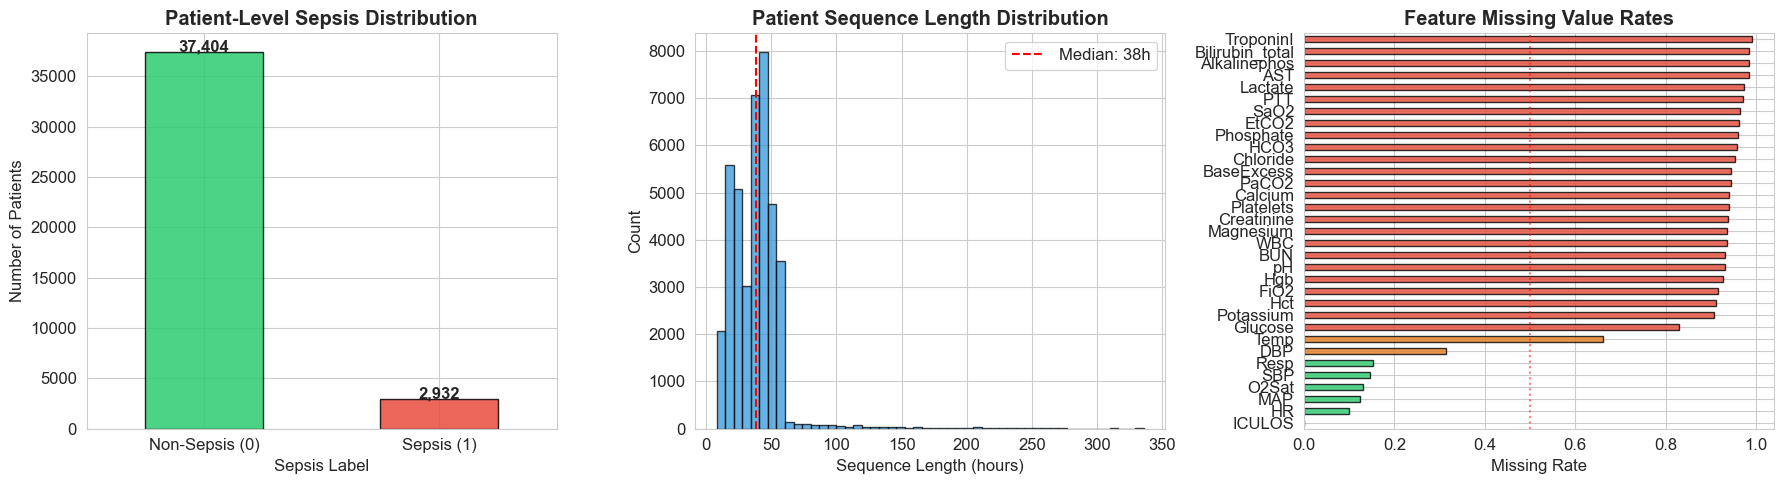

📊 EDA overview saved to eda_overview.png


In [8]:
# ─── Visualization: Label & Sequence Distribution ───
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Class distribution (patient-level)
colors = ['#2ecc71', '#e74c3c']
patient_label_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black', alpha=0.85)
axes[0].set_title('Patient-Level Sepsis Distribution', fontweight='bold')
axes[0].set_xlabel('Sepsis Label')
axes[0].set_ylabel('Number of Patients')
axes[0].set_xticklabels(['Non-Sepsis (0)', 'Sepsis (1)'], rotation=0)
for i, v in enumerate(patient_label_counts.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

# Sequence length distribution
axes[1].hist(seq_lengths.values, bins=50, color='#3498db', edgecolor='black', alpha=0.75)
axes[1].axvline(seq_lengths.median(), color='red', linestyle='--', label=f'Median: {seq_lengths.median():.0f}h')
axes[1].set_title('Patient Sequence Length Distribution', fontweight='bold')
axes[1].set_xlabel('Sequence Length (hours)')
axes[1].set_ylabel('Count')
axes[1].legend()

# Missing value rates
all_feature_cols = VITAL_COLS + LAB_COLS
miss_rates = df[all_feature_cols].isna().mean().sort_values(ascending=True)
colors_bar = ['#2ecc71' if v < 0.3 else '#e67e22' if v < 0.7 else '#e74c3c' for v in miss_rates.values]
miss_rates.plot(kind='barh', ax=axes[2], color=colors_bar, edgecolor='black', alpha=0.8)
axes[2].set_title('Feature Missing Value Rates', fontweight='bold')
axes[2].set_xlabel('Missing Rate')
axes[2].axvline(0.5, color='red', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 EDA overview saved to eda_overview.png")

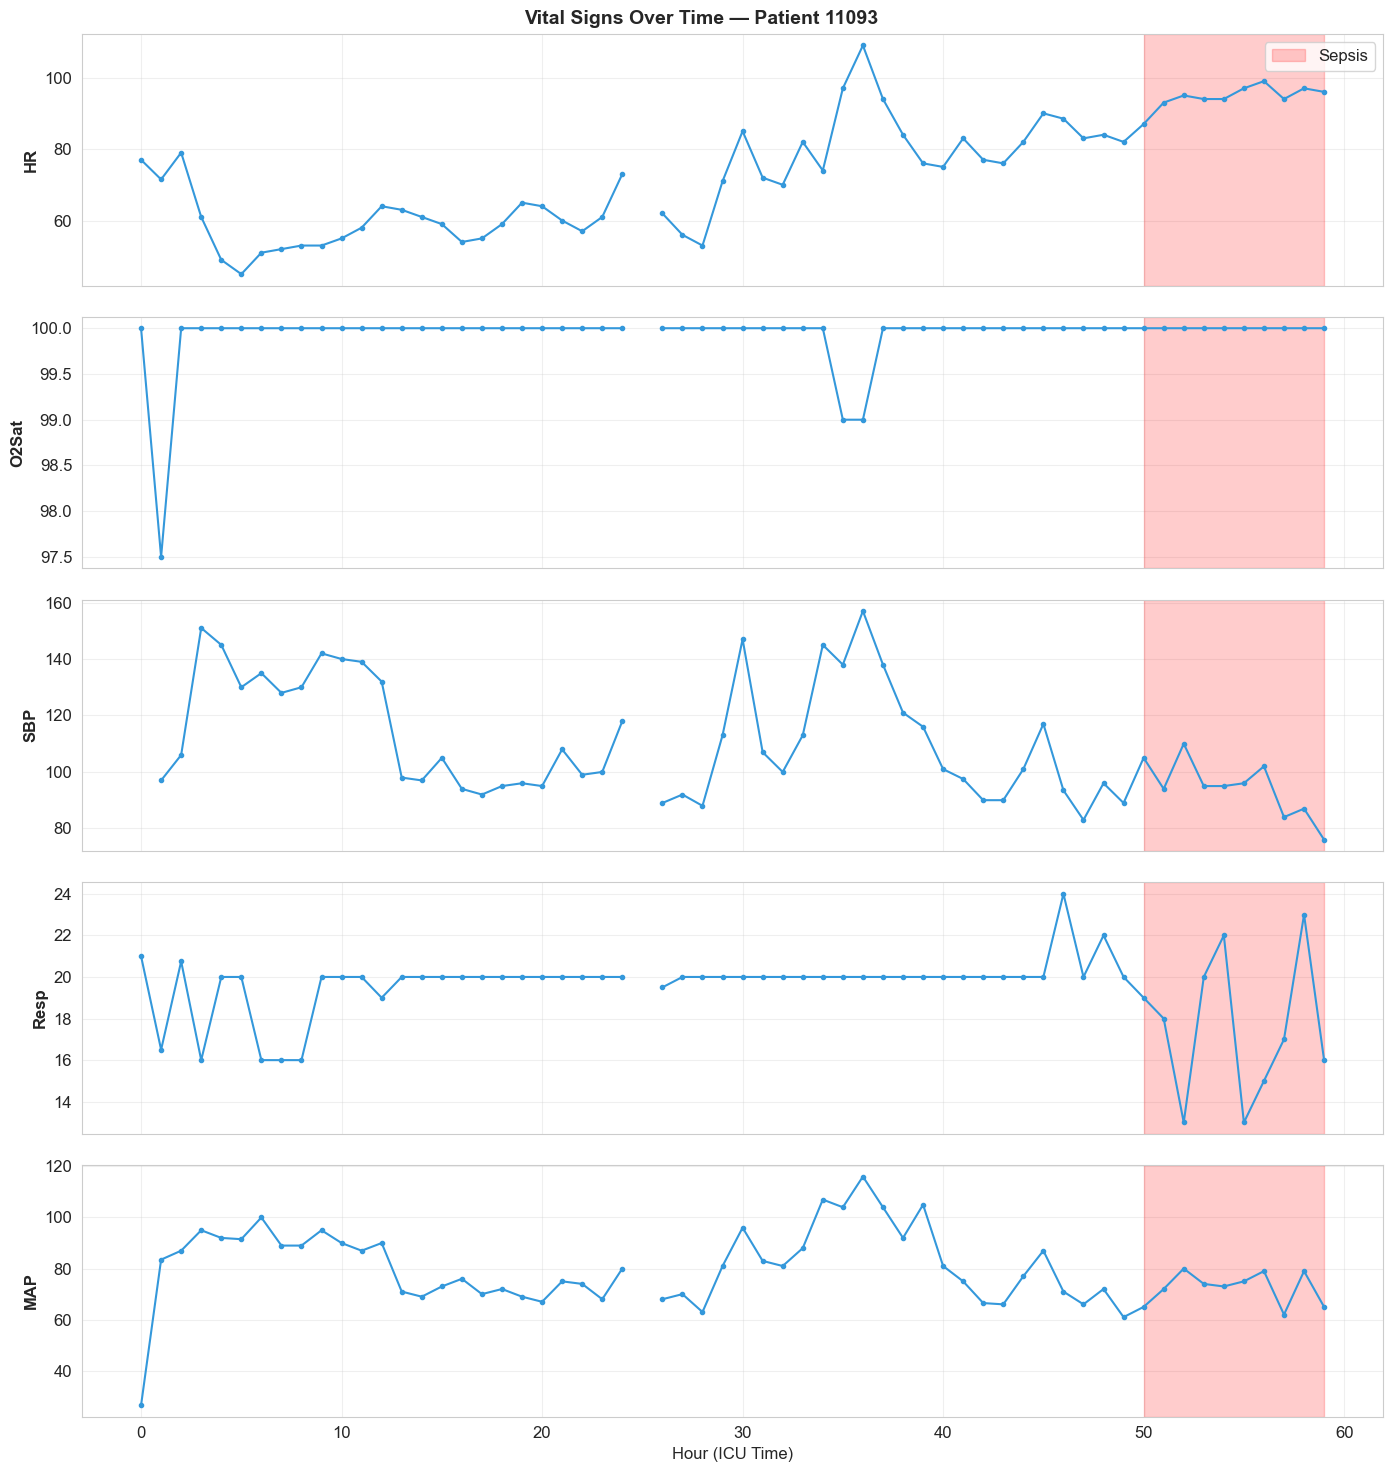

In [9]:
# ─── Vital signs temporal patterns for a sample patient ───
sample_sepsis = df[df[LABEL_COL] == 1][PATIENT_ID_COL].unique()
sample_pid = sample_sepsis[0] if len(sample_sepsis) > 0 else df[PATIENT_ID_COL].unique()[0]
patient_data = df[df[PATIENT_ID_COL] == sample_pid]

plot_vitals = [c for c in ['HR', 'O2Sat', 'Temp', 'SBP', 'Resp', 'MAP'] if c in VITAL_COLS]
n_plots = len(plot_vitals)

if n_plots > 0:
    fig, axes = plt.subplots(n_plots, 1, figsize=(14, 3 * n_plots), sharex=True)
    if n_plots == 1:
        axes = [axes]
    for i, col in enumerate(plot_vitals):
        axes[i].plot(patient_data[TIME_COL], patient_data[col], 'o-', markersize=3, linewidth=1.5, color='#3498db')
        # Shade sepsis onset
        sepsis_onset = patient_data[patient_data[LABEL_COL] == 1][TIME_COL]
        if len(sepsis_onset) > 0:
            axes[i].axvspan(sepsis_onset.min(), sepsis_onset.max(), alpha=0.2, color='red', label='Sepsis')
        axes[i].set_ylabel(col, fontweight='bold')
        axes[i].grid(True, alpha=0.3)
        if i == 0:
            axes[i].legend(loc='upper right')
    axes[-1].set_xlabel('Hour (ICU Time)')
    fig.suptitle(f'Vital Signs Over Time — Patient {sample_pid}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('vital_signs_sample.png', dpi=150, bbox_inches='tight')
    plt.show()

## 4. Data Preprocessing & Feature Engineering

In [10]:
# ─── Subsample patients for faster training (optional) ───
if CONFIG['MAX_PATIENTS'] is not None:
    all_pids = df[PATIENT_ID_COL].unique()
    if len(all_pids) > CONFIG['MAX_PATIENTS']:
        # Keep proportional sepsis ratio
        sepsis_pids = patient_labels[patient_labels == 1].index.tolist()
        nonsepsis_pids = patient_labels[patient_labels == 0].index.tolist()
        ratio = len(sepsis_pids) / len(all_pids)
        n_sep = max(1, int(CONFIG['MAX_PATIENTS'] * ratio))
        n_non = CONFIG['MAX_PATIENTS'] - n_sep
        selected = random.sample(sepsis_pids, min(n_sep, len(sepsis_pids))) + \
                   random.sample(nonsepsis_pids, min(n_non, len(nonsepsis_pids)))
        df = df[df[PATIENT_ID_COL].isin(selected)].reset_index(drop=True)
        print(f"⚡ Subsampled to {len(selected)} patients ({len(df):,} rows)")
    else:
        print(f"Using all {len(all_pids)} patients")
else:
    print(f"Using all {df[PATIENT_ID_COL].nunique():,} patients ({len(df):,} rows)")

Using all 40,336 patients (1,552,210 rows)


In [11]:
# Define all feature columns to use
STATIC_DEMO = [c for c in DEMOGRAPHIC_COLS if c in df.columns]
ALL_TEMPORAL_FEATURES = VITAL_COLS + LAB_COLS

for col in ['Unit1', 'Unit2']:
    if col in df.columns:
        df[col] = df[col].fillna(0)

print(f"Temporal features: {len(ALL_TEMPORAL_FEATURES)}")
print(f"Static demographics: {len(STATIC_DEMO)}")
print(f"Total features before engineering: {len(ALL_TEMPORAL_FEATURES) + len(STATIC_DEMO)}")

Temporal features: 33
Static demographics: 7
Total features before engineering: 40


In [12]:
# ─── Missing Value Imputation ───
print("Imputing missing values...")
print(f"  Before imputation — total NaNs: {df[ALL_TEMPORAL_FEATURES].isna().sum().sum():,}")

# Step 1: Forward-fill then backward-fill within each patient
df[ALL_TEMPORAL_FEATURES] = df.groupby(PATIENT_ID_COL)[ALL_TEMPORAL_FEATURES].transform(
    lambda x: x.ffill().bfill()
)
print(f"  After ffill+bfill   — total NaNs: {df[ALL_TEMPORAL_FEATURES].isna().sum().sum():,}")

# Step 2: Global median imputation for remaining NaNs
global_medians = df[ALL_TEMPORAL_FEATURES].median()
df[ALL_TEMPORAL_FEATURES] = df[ALL_TEMPORAL_FEATURES].fillna(global_medians)
print(f"  After median fill   — total NaNs: {df[ALL_TEMPORAL_FEATURES].isna().sum().sum():,}")

# Fill demographic NaNs
for col in STATIC_DEMO:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].median())

print("✅ Imputation complete — zero NaNs remain")

Imputing missing values...
  Before imputation — total NaNs: 39,197,039
  After ffill+bfill   — total NaNs: 14,219,163
  After median fill   — total NaNs: 0
✅ Imputation complete — zero NaNs remain


In [ ]:
# Missing Value Imputation (enhanced for highly sparse ICU series)
print("Imputing missing values with temporal + hierarchical strategy...")
print(f"  Before imputation - total NaNs: {df[ALL_TEMPORAL_FEATURES].isna().sum().sum():,}")

# Keep original missing map for diagnostics/features
raw_missing_map = df[ALL_TEMPORAL_FEATURES].isna().copy()

# 1) Sort by patient/time for valid temporal interpolation
df = df.sort_values([PATIENT_ID_COL, TIME_COL]).reset_index(drop=True)

# 2) Patient-wise linear interpolation for vital-like variables
if len(VITAL_COLS) > 0:
    df[VITAL_COLS] = df.groupby(PATIENT_ID_COL)[VITAL_COLS].transform(
        lambda x: x.interpolate(method='linear', limit_direction='both')
    )

# 3) Patient-wise ffill/bfill for all temporal variables
df[ALL_TEMPORAL_FEATURES] = df.groupby(PATIENT_ID_COL)[ALL_TEMPORAL_FEATURES].transform(
    lambda x: x.ffill().bfill()
    )
print(f"  After temporal fill - total NaNs: {df[ALL_TEMPORAL_FEATURES].isna().sum().sum():,}")

# 4) Patient-level median fallback then global median fallback
patient_median_filled = []
for col in ALL_TEMPORAL_FEATURES:
    patient_med = df.groupby(PATIENT_ID_COL)[col].transform('median')
    df[col] = df[col].fillna(patient_med)
    patient_median_filled.append(col)

global_medians = df[ALL_TEMPORAL_FEATURES].median(numeric_only=True)
df[ALL_TEMPORAL_FEATURES] = df[ALL_TEMPORAL_FEATURES].fillna(global_medians)

# 5) Static feature imputation
for col in STATIC_DEMO:
    if df[col].isna().any():
        med = pd.to_numeric(df[col], errors='coerce').median()
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(med if pd.notna(med) else 0.0)

# 6) Final finite-value cleanup
df[ALL_TEMPORAL_FEATURES] = df[ALL_TEMPORAL_FEATURES].replace([np.inf, -np.inf], np.nan).fillna(global_medians)

print(f"  After hierarchical fill - total NaNs: {df[ALL_TEMPORAL_FEATURES].isna().sum().sum():,}")
print("Imputation complete")

Engineering missingness indicator features...
  Created 27 missingness indicator features
Computing rolling statistics for vital signs...


KeyboardInterrupt: 

# Feature Engineering: Missingness Indicators + Time-Since-Observed
print("Engineering missingness and temporal reliability features...")

df_raw = pd.read_csv(dataset_file)
unnamed_cols_raw = [c for c in df_raw.columns if 'Unnamed' in str(c)]
if unnamed_cols_raw:
    df_raw = df_raw.drop(columns=unnamed_cols_raw)

if CONFIG['MAX_PATIENTS'] is not None:
    df_raw = df_raw[df_raw[PATIENT_ID_COL].isin(df[PATIENT_ID_COL].unique())].reset_index(drop=True)

df_raw = df_raw.sort_values([PATIENT_ID_COL, TIME_COL]).reset_index(drop=True)

join_keys = [PATIENT_ID_COL, TIME_COL]
missing_cols = [c for c in LAB_COLS if c in df_raw.columns]
missing_map = df_raw[join_keys + missing_cols].copy()
for c in missing_cols:
    missing_map[c] = missing_map[c].isna().astype(np.float32)

MASK_COLS = []
DELTA_COLS = []

def time_since_last_observed(mask_series):
    mask = mask_series.to_numpy(dtype=np.float32)
    out = np.zeros_like(mask, dtype=np.float32)
    counter = 0.0
    for i, m in enumerate(mask):
        if m < 0.5:
            counter = 0.0
        else:
            counter += 1.0
        out[i] = counter
    return pd.Series(out, index=mask_series.index)

for col in LAB_COLS:
    mask_col = f"{col}_missing"
    delta_col = f"{col}_tsince_obs"

    if col in missing_map.columns:
        aligned = df[join_keys].merge(
            missing_map[join_keys + [col]], on=join_keys, how='left'
        )[col].fillna(1.0).astype(np.float32)
        df[mask_col] = aligned.values
    else:
        df[mask_col] = np.ones(len(df), dtype=np.float32)

    df[delta_col] = df.groupby(PATIENT_ID_COL)[mask_col].transform(time_since_last_observed)
    MASK_COLS.append(mask_col)
    DELTA_COLS.append(delta_col)

print(f"  Created {len(MASK_COLS)} missingness indicator features")
print(f"  Created {len(DELTA_COLS)} time-since-observation features")
del df_raw

# Feature Engineering: Rolling Statistics for Vital Signs
print("Computing rolling statistics for vital signs...")
ROLLING_COLS = []
WINDOW = 6

for col in VITAL_COLS:
    roll_mean_col = f"{col}_roll_mean"
    roll_std_col = f"{col}_roll_std"
    df[roll_mean_col] = df.groupby(PATIENT_ID_COL)[col].transform(
        lambda x: x.rolling(window=WINDOW, min_periods=1).mean()
    )
    df[roll_std_col] = df.groupby(PATIENT_ID_COL)[col].transform(
        lambda x: x.rolling(window=WINDOW, min_periods=1).std().fillna(0)
    )
    ROLLING_COLS.extend([roll_mean_col, roll_std_col])

print(f"  Created {len(ROLLING_COLS)} rolling statistic features")

FINAL_FEATURES = ALL_TEMPORAL_FEATURES + STATIC_DEMO + MASK_COLS + DELTA_COLS + ROLLING_COLS
df[FINAL_FEATURES] = df[FINAL_FEATURES].replace([np.inf, -np.inf], np.nan).fillna(0.0)

print(f"\nTotal features after engineering: {len(FINAL_FEATURES)}")
CONFIG['INPUT_DIM'] = len(FINAL_FEATURES)

In [1]:
# Train / Validation / Test Split (Patient-Level, leakage-safe)
df_split_base = df.dropna(subset=[PATIENT_ID_COL]).copy()
dropped_pid_rows = len(df) - len(df_split_base)
if dropped_pid_rows > 0:
    print(f"Warning: dropped {dropped_pid_rows:,} rows with missing patient IDs before splitting")

all_patient_ids = df_split_base[PATIENT_ID_COL].unique()
patient_labels = df_split_base.groupby(PATIENT_ID_COL)[LABEL_COL].max()

# Guard against any unexpected ID/label index mismatch
patient_labels = patient_labels.reindex(all_patient_ids)
valid_id_mask = patient_labels.notna().values
if not np.all(valid_id_mask):
    bad_ids = np.sum(~valid_id_mask)
    print(f"Warning: dropping {bad_ids} patient IDs with missing aggregated labels")
    all_patient_ids = all_patient_ids[valid_id_mask]
    patient_labels = patient_labels[valid_id_mask]

print(f"Total patients: {len(all_patient_ids):,}")

strat_labels = patient_labels.values
class_counts = Counter(strat_labels.tolist())
can_stratify = len(class_counts) > 1 and min(class_counts.values()) >= 3
if not can_stratify:
    print("Warning: insufficient class counts for stable stratification; falling back to non-stratified split")
    strat_labels = None

train_val_ids, test_ids = train_test_split(
    all_patient_ids,
    test_size=CONFIG['TEST_SIZE'],
    random_state=CONFIG['SEED'],
    stratify=strat_labels
)

adjusted_val = CONFIG['VAL_SIZE'] / (1 - CONFIG['TEST_SIZE'])
if strat_labels is not None:
    train_val_strat = patient_labels.loc[train_val_ids].values
    if len(np.unique(train_val_strat)) < 2 or min(Counter(train_val_strat.tolist()).values()) < 2:
        train_val_strat = None
else:
    train_val_strat = None

train_ids, val_ids = train_test_split(
    train_val_ids,
    test_size=adjusted_val,
    random_state=CONFIG['SEED'],
    stratify=train_val_strat
)

print(f"Train patients: {len(train_ids):,}")
print(f"Val patients:   {len(val_ids):,}")
print(f"Test patients:  {len(test_ids):,}")

assert len(set(train_ids) & set(val_ids)) == 0, "Data leakage: train/val overlap"
assert len(set(train_ids) & set(test_ids)) == 0, "Data leakage: train/test overlap"
assert len(set(val_ids) & set(test_ids)) == 0, "Data leakage: val/test overlap"
print("No patient-level data leakage detected")

NameError: name 'df' is not defined

In [ ]:
# Normalization: Fit scaler on TRAIN set only
print("Fitting StandardScaler on training data...")

train_df = df[df[PATIENT_ID_COL].isin(train_ids)].copy()
val_df = df[df[PATIENT_ID_COL].isin(val_ids)].copy()
test_df = df[df[PATIENT_ID_COL].isin(test_ids)].copy()

# Replace inf with NaN before scaling
for split_df in [train_df, val_df, test_df]:
    split_df[FINAL_FEATURES] = split_df[FINAL_FEATURES].replace([np.inf, -np.inf], np.nan)

# Ensure train fit has no NaN left
train_df[FINAL_FEATURES] = train_df[FINAL_FEATURES].fillna(global_medians)
val_df[FINAL_FEATURES] = val_df[FINAL_FEATURES].fillna(global_medians)
test_df[FINAL_FEATURES] = test_df[FINAL_FEATURES].fillna(global_medians)

scaler = StandardScaler()
scaler.fit(train_df[FINAL_FEATURES])

train_df_scaled = train_df.copy()
val_df_scaled = val_df.copy()
test_df_scaled = test_df.copy()

train_df_scaled[FINAL_FEATURES] = scaler.transform(train_df[FINAL_FEATURES])
val_df_scaled[FINAL_FEATURES] = scaler.transform(val_df[FINAL_FEATURES])
test_df_scaled[FINAL_FEATURES] = scaler.transform(test_df[FINAL_FEATURES])

# Final finite-value guard after scaling
for split_name, split_df in [('train', train_df_scaled), ('val', val_df_scaled), ('test', test_df_scaled)]:
    arr = split_df[FINAL_FEATURES].to_numpy(dtype=np.float32)
    non_finite = int((~np.isfinite(arr)).sum())
    if non_finite > 0:
        print(f"Warning: {split_name} split had {non_finite:,} non-finite values after scaling; replacing with 0")
        split_df[FINAL_FEATURES] = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)

print(f"Scaler fitted on {len(train_df):,} training rows")
print(f"Feature means (sample): {scaler.mean_[:3].round(3)}")
print(f"Feature stds (sample):  {scaler.scale_[:3].round(3)}")

In [ ]:
# Normalization: robust clipping + scaler fit on TRAIN only
print("Fitting StandardScaler on training data with robust clipping...")

train_df = df[df[PATIENT_ID_COL].isin(train_ids)].copy()
val_df = df[df[PATIENT_ID_COL].isin(val_ids)].copy()
test_df = df[df[PATIENT_ID_COL].isin(test_ids)].copy()

for split_df in [train_df, val_df, test_df]:
    split_df[FINAL_FEATURES] = split_df[FINAL_FEATURES].replace([np.inf, -np.inf], np.nan).fillna(0.0)

# Train-only clipping thresholds to reduce outlier-driven overfit
clip_lower = train_df[FINAL_FEATURES].quantile(CONFIG['CLIP_LOWER_Q'])
clip_upper = train_df[FINAL_FEATURES].quantile(CONFIG['CLIP_UPPER_Q'])

for split_df in [train_df, val_df, test_df]:
    split_df[FINAL_FEATURES] = split_df[FINAL_FEATURES].clip(lower=clip_lower, upper=clip_upper, axis=1)

scaler = StandardScaler()
scaler.fit(train_df[FINAL_FEATURES])

train_df_scaled = train_df.copy()
val_df_scaled = val_df.copy()
test_df_scaled = test_df.copy()

train_df_scaled[FINAL_FEATURES] = scaler.transform(train_df[FINAL_FEATURES])
val_df_scaled[FINAL_FEATURES] = scaler.transform(val_df[FINAL_FEATURES])
test_df_scaled[FINAL_FEATURES] = scaler.transform(test_df[FINAL_FEATURES])

for split_name, split_df in [('train', train_df_scaled), ('val', val_df_scaled), ('test', test_df_scaled)]:
    arr = split_df[FINAL_FEATURES].to_numpy(dtype=np.float32)
    non_finite = int((~np.isfinite(arr)).sum())
    if non_finite > 0:
        print(f"Warning: {split_name} split had {non_finite:,} non-finite values after scaling; replacing with 0")
        split_df[FINAL_FEATURES] = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)

print(f"Scaler fitted on {len(train_df):,} training rows")
print(f"Feature means (sample): {scaler.mean_[:3].round(3)}")
print(f"Feature stds (sample):  {scaler.scale_[:3].round(3)}")

## 6. PyTorch Dataset & DataLoaders

In [ ]:
class SepsisDataset(Dataset):
    """PyTorch Dataset for sepsis prediction windows."""

    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

def _create_windows_inline(df_split, patient_ids, seq_len, stride, label_col, label_strategy='any_positive_window'):
    X_windows, y_windows = [], []
    for pid in patient_ids:
        p_data = df_split[df_split[PATIENT_ID_COL] == pid].sort_values(TIME_COL)
        if len(p_data) == 0:
            continue

        features = p_data[FINAL_FEATURES].values.astype(np.float32)
        labels = pd.to_numeric(p_data[label_col], errors='coerce').fillna(0).values.astype(np.float32)
        features = np.nan_to_num(features, nan=0.0, posinf=0.0, neginf=0.0)
        labels = (np.nan_to_num(labels, nan=0.0, posinf=1.0, neginf=0.0) > 0.5).astype(np.float32)

        T = len(features)
        if T <= seq_len:
            pad_len = seq_len - T
            padded_feat = np.vstack([
                np.zeros((pad_len, features.shape[1]), dtype=np.float32),
                features
            ])
            X_windows.append(padded_feat)
            y_windows.append(float(labels.max() if label_strategy == 'any_positive_window' else labels[-1]))
            continue

        for start in range(0, T - seq_len + 1, stride):
            window_feat = features[start:start + seq_len]
            window_labels = labels[start:start + seq_len]
            X_windows.append(window_feat)
            y_windows.append(float(window_labels.max() if label_strategy == 'any_positive_window' else window_labels[-1]))

    X = np.array(X_windows, dtype=np.float32)
    y = np.array(y_windows, dtype=np.float32)
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    y = np.nan_to_num(y, nan=0.0, posinf=1.0, neginf=0.0)
    return X, y

# Auto-recover when cells are run out of order
required_for_windows = ['train_df_scaled', 'val_df_scaled', 'test_df_scaled', 'train_ids', 'val_ids', 'test_ids']
missing_for_windows = [v for v in required_for_windows if v not in globals()]

if any(v not in globals() for v in ['X_train', 'y_train', 'X_val', 'y_val', 'X_test', 'y_test']):
    if missing_for_windows:
        raise RuntimeError(
            "Window tensors are missing and cannot be auto-created. Run the split/scaling cells first. "
            f"Missing prerequisites: {missing_for_windows}"
        )
    print("Window arrays not found; creating windows now...")
    create_fn = globals().get('create_windows', _create_windows_inline)
    X_train, y_train = create_fn(
        train_df_scaled, train_ids, CONFIG['SEQUENCE_LENGTH'], CONFIG['STRIDE'], LABEL_COL, CONFIG['LABEL_STRATEGY']
    )
    X_val, y_val = create_fn(
        val_df_scaled, val_ids, CONFIG['SEQUENCE_LENGTH'], CONFIG['STRIDE'], LABEL_COL, CONFIG['LABEL_STRATEGY']
    )
    X_test, y_test = create_fn(
        test_df_scaled, test_ids, CONFIG['SEQUENCE_LENGTH'], CONFIG['STRIDE'], LABEL_COL, CONFIG['LABEL_STRATEGY']
    )
    print(f"Auto-created windows: Train {X_train.shape}, Val {X_val.shape}, Test {X_test.shape}")

train_dataset = SepsisDataset(X_train, y_train)
val_dataset = SepsisDataset(X_val, y_val)
test_dataset = SepsisDataset(X_test, y_test)

class_counts = Counter(y_train.astype(int).tolist())
total = len(y_train)
class_weights = {c: total / (2.0 * count) for c, count in class_counts.items()}
sample_weights = [class_weights[int(label)] for label in y_train]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

print(f"Class weights: {class_weights}")

train_loader = DataLoader(
    train_dataset, batch_size=CONFIG['BATCH_SIZE'], sampler=sampler,
    num_workers=0, pin_memory=True, drop_last=True
    )
val_loader = DataLoader(
    val_dataset, batch_size=CONFIG['BATCH_SIZE'], shuffle=False,
    num_workers=0, pin_memory=True
    )
test_loader = DataLoader(
    test_dataset, batch_size=CONFIG['BATCH_SIZE'], shuffle=False,
    num_workers=0, pin_memory=True
    )

print("\nDataLoaders created:")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

In [ ]:
# Positional Encoding
class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding for transformer inputs."""

    def __init__(self, d_model, max_len=500, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term[: pe[:, 1::2].shape[1]])
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


class CausalConvBlock(nn.Module):
    """Single branch of causal dilated temporal convolution."""

    def __init__(self, in_channels, out_channels, kernel_size, dilation, dropout=0.2):
        super().__init__()
        self.padding = (kernel_size - 1) * dilation
        self.conv = nn.Conv1d(
            in_channels, out_channels, kernel_size,
            padding=self.padding, dilation=dilation
        )
        self.bn = nn.BatchNorm1d(out_channels)
        self.activation = nn.GELU()
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = self.conv(x)
        out = out[:, :, :x.size(2)]
        out = self.bn(out)
        out = self.activation(out)
        out = self.dropout(out)
        return out


class MultiScaleTCN(nn.Module):
    """Parallel dilated causal convolutions at multiple scales."""

    def __init__(self, in_channels, tcn_channels, kernel_sizes, dilations, tcn_dropout=0.2):
        super().__init__()
        self.branches = nn.ModuleList()
        for ks in kernel_sizes:
            branch = nn.Sequential(*[
                CausalConvBlock(
                    in_channels if i == 0 else tcn_channels,
                    tcn_channels, ks, d, dropout=tcn_dropout
                ) for i, d in enumerate(dilations)
            ])
            self.branches.append(branch)

        total_channels = tcn_channels * len(kernel_sizes)
        self.fusion = nn.Sequential(
            nn.Conv1d(total_channels, tcn_channels, 1),
            nn.BatchNorm1d(tcn_channels),
            nn.GELU(),
            nn.Dropout(tcn_dropout)
        )

    def forward(self, x):
        branch_outputs = [branch(x) for branch in self.branches]
        concat = torch.cat(branch_outputs, dim=1)
        return self.fusion(concat)


print("TCN components defined")

# Full MSTCT Model
class MSTCT(nn.Module):
    """Multi-Scale Temporal Convolutional Transformer for sepsis prediction."""

    def __init__(self, config):
        super().__init__()
        input_dim = config['INPUT_DIM']
        tcn_channels = config['TCN_CHANNELS']
        kernel_sizes = config['TCN_KERNEL_SIZES']
        dilations = config['TCN_DILATIONS']
        tf_dim = config['TRANSFORMER_DIM']
        tf_heads = config['TRANSFORMER_HEADS']
        tf_layers = config['TRANSFORMER_LAYERS']
        tf_ff_dim = config['TRANSFORMER_FF_DIM']
        dropout = config['DROPOUT']
        tcn_dropout = config.get('TCN_DROPOUT', 0.2)

        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, tcn_channels),
            nn.LayerNorm(tcn_channels),
            nn.GELU(),
            nn.Dropout(dropout)
        )
        self.tcn = MultiScaleTCN(
            tcn_channels, tcn_channels, kernel_sizes, dilations, tcn_dropout=tcn_dropout
        )
        self.tcn_to_transformer = nn.Sequential(
            nn.Linear(tcn_channels, tf_dim),
            nn.LayerNorm(tf_dim),
            nn.Dropout(dropout)
        )
        self.pos_encoder = PositionalEncoding(tf_dim, dropout=dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=tf_dim,
            nhead=tf_heads,
            dim_feedforward=tf_ff_dim,
            dropout=dropout,
            activation='gelu',
            batch_first=True,
            norm_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=tf_layers)
        self.classifier = nn.Sequential(
            nn.Linear(tf_dim, tf_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(tf_dim // 2, 1)
        )

    def forward(self, x):
        x = self.input_proj(x)
        x = x.permute(0, 2, 1)
        x = self.tcn(x)
        x = x.permute(0, 2, 1)
        x = self.tcn_to_transformer(x)

        padding_mask = torch.isclose(
            x.abs().sum(dim=-1),
            torch.zeros(1, device=x.device),
            atol=1e-12
        )

        x = self.pos_encoder(x)
        x = self.transformer(x, src_key_padding_mask=padding_mask)

        valid_mask = (~padding_mask).float().unsqueeze(-1)
        denom = valid_mask.sum(dim=1).clamp(min=1.0)
        x = (x * valid_mask).sum(dim=1) / denom

        logits = self.classifier(x)
        return logits.squeeze(-1)

model = MSTCT(CONFIG).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("MSTCT Model Summary")
print(f"Input dimension:  {CONFIG['INPUT_DIM']}")
print(f"TCN channels:     {CONFIG['TCN_CHANNELS']}")
print(f"Transformer dim:  {CONFIG['TRANSFORMER_DIM']}")
print(f"Total parameters: {n_params:,}")
print(f"Device:           {DEVICE}")

In [ ]:
# ─── Loss Function & Optimizer ───
# Compute positive class weight for BCE
pos_weight_val = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
pos_weight_tensor = torch.tensor([pos_weight_val], dtype=torch.float32).to(DEVICE)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG['LEARNING_RATE'],
                               weight_decay=CONFIG['WEIGHT_DECAY'])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG['EPOCHS'], eta_min=1e-6)

print(f"Loss: BCEWithLogitsLoss (pos_weight={pos_weight_val:.2f})")
print(f"Optimizer: AdamW (lr={CONFIG['LEARNING_RATE']}, wd={CONFIG['WEIGHT_DECAY']})")
print(f"Scheduler: CosineAnnealingLR (T_max={CONFIG['EPOCHS']})")

In [ ]:
# Training & Validation Functions
def safe_auc_metrics(labels, probs):
    labels = np.asarray(labels, dtype=np.float32)
    probs = np.asarray(probs, dtype=np.float32)

    finite_mask = np.isfinite(labels) & np.isfinite(probs)
    labels = labels[finite_mask]
    probs = probs[finite_mask]

    if len(labels) == 0 or len(np.unique(labels)) < 2:
        return np.nan, np.nan
    return roc_auc_score(labels, probs), average_precision_score(labels, probs)

def train_one_epoch(model, loader, criterion, optimizer, device, grad_clip):
    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []

    for X_batch, y_batch in loader:
        X_batch = torch.nan_to_num(X_batch.to(device), nan=0.0, posinf=0.0, neginf=0.0)
        y_batch = torch.nan_to_num(y_batch.to(device), nan=0.0, posinf=1.0, neginf=0.0)

        optimizer.zero_grad()
        logits = model(X_batch)
        logits = torch.nan_to_num(logits, nan=0.0, posinf=20.0, neginf=-20.0)
        loss = criterion(logits, y_batch)
        if not torch.isfinite(loss):
            continue
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()

        total_loss += loss.item() * len(y_batch)
        probs = torch.sigmoid(logits).detach().cpu().numpy()
        probs = np.nan_to_num(probs, nan=0.5, posinf=1.0, neginf=0.0)
        all_preds.extend(probs.tolist())
        all_labels.extend(y_batch.detach().cpu().numpy().tolist())

    denom = max(len(loader.dataset), 1)
    avg_loss = total_loss / denom
    auroc, auprc = safe_auc_metrics(all_labels, all_preds)
    return avg_loss, auroc, auprc


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    for X_batch, y_batch in loader:
        X_batch = torch.nan_to_num(X_batch.to(device), nan=0.0, posinf=0.0, neginf=0.0)
        y_batch = torch.nan_to_num(y_batch.to(device), nan=0.0, posinf=1.0, neginf=0.0)

        logits = model(X_batch)
        logits = torch.nan_to_num(logits, nan=0.0, posinf=20.0, neginf=-20.0)
        loss = criterion(logits, y_batch)
        if not torch.isfinite(loss):
            continue

        total_loss += loss.item() * len(y_batch)
        probs = torch.sigmoid(logits).cpu().numpy()
        probs = np.nan_to_num(probs, nan=0.5, posinf=1.0, neginf=0.0)
        all_preds.extend(probs.tolist())
        all_labels.extend(y_batch.cpu().numpy().tolist())

    denom = max(len(loader.dataset), 1)
    avg_loss = total_loss / denom
    all_preds = np.array(all_preds, dtype=np.float32)
    all_labels = np.array(all_labels, dtype=np.float32)
    auroc, auprc = safe_auc_metrics(all_labels, all_preds)
    return avg_loss, auroc, auprc, all_preds, all_labels

print("Training and evaluation functions defined")

In [ ]:
# Training Loop with Early Stopping
print("=" * 70)
print("TRAINING MSTCT MODEL")
print("=" * 70)

history = {
    'train_loss': [], 'val_loss': [],
    'train_auroc': [], 'val_auroc': [],
    'train_auprc': [], 'val_auprc': [],
    'lr': []
}

best_val_auroc = -np.inf
best_epoch = 0
patience_counter = 0
best_model_state = None

for epoch in range(1, CONFIG['EPOCHS'] + 1):
    train_loss, train_auroc, train_auprc = train_one_epoch(
        model, train_loader, criterion, optimizer, DEVICE, CONFIG['GRAD_CLIP']
    )
    val_loss, val_auroc, val_auprc, _, _ = evaluate(model, val_loader, criterion, DEVICE)

    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_auroc'].append(train_auroc)
    history['val_auroc'].append(val_auroc)
    history['train_auprc'].append(train_auprc)
    history['val_auprc'].append(val_auprc)
    history['lr'].append(current_lr)

    val_score = -np.inf if np.isnan(val_auroc) else val_auroc
    if val_score > best_val_auroc:
        best_val_auroc = val_score
        best_epoch = epoch
        patience_counter = 0
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        status_text = "Best"
    else:
        patience_counter += 1
        status_text = f"Patience: {patience_counter}/{CONFIG['PATIENCE']}"

    print(
        f"Epoch {epoch:>3}/{CONFIG['EPOCHS']} | "
        f"Train Loss: {train_loss:.4f} AUROC: {train_auroc:.4f} AUPRC: {train_auprc:.4f} | "
        f"Val Loss: {val_loss:.4f} AUROC: {val_auroc:.4f} AUPRC: {val_auprc:.4f} | "
        f"LR: {current_lr:.2e} | {status_text}"
    )

    if patience_counter >= CONFIG['PATIENCE']:
        print(f"\nEarly stopping at epoch {epoch} (best epoch: {best_epoch})")
        break

if best_model_state is not None:
    model.load_state_dict(best_model_state)
    best_val_display = best_val_auroc if np.isfinite(best_val_auroc) else float('nan')
    print(f"\nRestored best model from epoch {best_epoch} (Val AUROC: {best_val_display:.4f})")

In [ ]:
# ─── Training Curves ───
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
epochs_range = range(1, len(history['train_loss']) + 1)

# Loss
axes[0].plot(epochs_range, history['train_loss'], 'b-o', markersize=4, label='Train')
axes[0].plot(epochs_range, history['val_loss'], 'r-o', markersize=4, label='Validation')
axes[0].axvline(best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best (epoch {best_epoch})')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# AUROC
axes[1].plot(epochs_range, history['train_auroc'], 'b-o', markersize=4, label='Train')
axes[1].plot(epochs_range, history['val_auroc'], 'r-o', markersize=4, label='Validation')
axes[1].axvline(best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best (epoch {best_epoch})')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUROC')
axes[1].set_title('AUROC Over Epochs', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# AUPRC
axes[2].plot(epochs_range, history['train_auprc'], 'b-o', markersize=4, label='Train')
axes[2].plot(epochs_range, history['val_auprc'], 'r-o', markersize=4, label='Validation')
axes[2].axvline(best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best (epoch {best_epoch})')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('AUPRC')
axes[2].set_title('AUPRC Over Epochs', fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Training curves saved to training_curves.png")

## 9. Model Evaluation & Visualization

In [ ]:
# Final Evaluation with threshold selected on validation set
val_loss, val_auroc, val_auprc, val_probs, val_labels = evaluate(
    model, val_loader, criterion, DEVICE
)
test_loss, test_auroc, test_auprc, test_probs, test_labels = evaluate(
    model, test_loader, criterion, DEVICE
)

# Select threshold on validation set (prevents test leakage)
val_fpr, val_tpr, val_thresholds = roc_curve(val_labels, val_probs)
val_j_scores = val_tpr - val_fpr
val_optimal_idx = np.argmax(val_j_scores)
optimal_threshold = val_thresholds[val_optimal_idx]

# Build test ROC and locate threshold marker
fpr, tpr, test_thresholds = roc_curve(test_labels, test_probs)
threshold_marker_idx = int(np.argmin(np.abs(test_thresholds - optimal_threshold)))

test_preds = (test_probs >= optimal_threshold).astype(int)

accuracy = accuracy_score(test_labels, test_preds)
precision = precision_score(test_labels, test_preds, zero_division=0)
recall = recall_score(test_labels, test_preds, zero_division=0)
f1 = f1_score(test_labels, test_preds, zero_division=0)

print("=" * 60)
print("TEST SET EVALUATION RESULTS")
print("=" * 60)
print(f"Validation-selected Threshold: {optimal_threshold:.4f}")
print(f"Accuracy:                     {accuracy:.4f}")
print(f"Precision:                    {precision:.4f}")
print(f"Recall:                       {recall:.4f}")
print(f"F1 Score:                     {f1:.4f}")
print(f"AUROC:                        {test_auroc:.4f}")
print(f"AUPRC:                        {test_auprc:.4f}")
print(f"\n{classification_report(test_labels, test_preds, target_names=['Non-Sepsis', 'Sepsis'])}")

In [ ]:
# Confusion Matrix
cm = confusion_matrix(test_labels, test_preds)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
    xticklabels=['Non-Sepsis', 'Sepsis'],
    yticklabels=['Non-Sepsis', 'Sepsis']
    )
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix', fontweight='bold')

axes[1].plot(fpr, tpr, 'b-', linewidth=2, label=f'MSTCT (AUROC = {test_auroc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
axes[1].plot(
    fpr[threshold_marker_idx], tpr[threshold_marker_idx],
    'ro', markersize=10, label=f'Val-selected t={optimal_threshold:.3f}'
    )
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

prec_curve, rec_curve, _ = precision_recall_curve(test_labels, test_probs)
axes[2].plot(rec_curve, prec_curve, 'g-', linewidth=2, label=f'MSTCT (AUPRC = {test_auprc:.4f})')
baseline = test_labels.mean()
axes[2].axhline(y=baseline, color='k', linestyle='--', alpha=0.5, label=f'Baseline ({baseline:.3f})')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve', fontweight='bold')
axes[2].legend(loc='upper right')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('evaluation_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Evaluation plots saved to evaluation_results.png")

## 10. Model Persistence (Save & Load)

In [ ]:
# ─── Save Model, Config, and Scaler ───
SAVE_DIR = os.path.join(os.getcwd(), 'saved_model')
os.makedirs(SAVE_DIR, exist_ok=True)

# 1. Model state dict
model_path = os.path.join(SAVE_DIR, 'mstct_sepsis_model.pth')
torch.save({
    'model_state_dict': model.state_dict(),
    'config': CONFIG,
    'optimal_threshold': optimal_threshold,
    'feature_columns': FINAL_FEATURES,
    'label_column': LABEL_COL,
    'patient_id_column': PATIENT_ID_COL,
    'time_column': TIME_COL,
    'history': history,
    'test_metrics': {
        'auroc': test_auroc, 'auprc': test_auprc,
        'accuracy': accuracy, 'precision': precision,
        'recall': recall, 'f1': f1
    }
}, model_path)
print(f"✅ Model saved to: {model_path}")

# 2. Scaler
scaler_path = os.path.join(SAVE_DIR, 'feature_scaler.pkl')
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f"✅ Scaler saved to: {scaler_path}")

# 3. Feature config
feature_config = {
    'FINAL_FEATURES': FINAL_FEATURES,
    'ALL_TEMPORAL_FEATURES': ALL_TEMPORAL_FEATURES,
    'VITAL_COLS': VITAL_COLS,
    'LAB_COLS': LAB_COLS,
    'STATIC_DEMO': STATIC_DEMO,
    'MASK_COLS': MASK_COLS,
    'ROLLING_COLS': ROLLING_COLS,
    'LABEL_COL': LABEL_COL,
    'PATIENT_ID_COL': PATIENT_ID_COL,
    'TIME_COL': TIME_COL,
    'global_medians': global_medians.to_dict()
}
config_path = os.path.join(SAVE_DIR, 'feature_config.json')
with open(config_path, 'w') as f:
    json.dump(feature_config, f, indent=2)
print(f"✅ Feature config saved to: {config_path}")

print(f"\n📁 All artifacts saved in: {SAVE_DIR}")

In [ ]:
# Save Model, Config, and Scaler
SAVE_DIR = os.path.join(os.getcwd(), 'saved_model')
os.makedirs(SAVE_DIR, exist_ok=True)

model_path = os.path.join(SAVE_DIR, 'mstct_sepsis_model.pth')
torch.save({
    'model_state_dict': model.state_dict(),
    'config': CONFIG,
    'optimal_threshold': optimal_threshold,
    'feature_columns': FINAL_FEATURES,
    'label_column': LABEL_COL,
    'patient_id_column': PATIENT_ID_COL,
    'time_column': TIME_COL,
    'history': history,
    'test_metrics': {
        'auroc': test_auroc, 'auprc': test_auprc,
        'accuracy': accuracy, 'precision': precision,
        'recall': recall, 'f1': f1
    }
}, model_path)
print(f"Model saved to: {model_path}")

scaler_path = os.path.join(SAVE_DIR, 'feature_scaler.pkl')
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f"Scaler saved to: {scaler_path}")

feature_config = {
    'FINAL_FEATURES': FINAL_FEATURES,
    'ALL_TEMPORAL_FEATURES': ALL_TEMPORAL_FEATURES,
    'VITAL_COLS': VITAL_COLS,
    'LAB_COLS': LAB_COLS,
    'STATIC_DEMO': STATIC_DEMO,
    'MASK_COLS': MASK_COLS,
    'DELTA_COLS': DELTA_COLS,
    'ROLLING_COLS': ROLLING_COLS,
    'LABEL_COL': LABEL_COL,
    'PATIENT_ID_COL': PATIENT_ID_COL,
    'TIME_COL': TIME_COL,
    'global_medians': global_medians.to_dict(),
    'clip_lower': clip_lower.to_dict(),
    'clip_upper': clip_upper.to_dict()
}
config_path = os.path.join(SAVE_DIR, 'feature_config.json')
with open(config_path, 'w') as f:
    json.dump(feature_config, f, indent=2)
print(f"Feature config saved to: {config_path}")

print(f"\nAll artifacts saved in: {SAVE_DIR}")

## 11. Inference Pipeline

In [ ]:
# Inference Function
def predict_sepsis(patient_data_df, model, scaler, feature_config, config, device, threshold):
    """Run inference on a new patient's time-series data."""
    model.eval()
    seq_len = config['SEQUENCE_LENGTH']
    stride = config.get('STRIDE', 12)

    temporal_features = feature_config['ALL_TEMPORAL_FEATURES']
    static_demo = feature_config['STATIC_DEMO']
    lab_cols = feature_config['LAB_COLS']
    vital_cols = feature_config['VITAL_COLS']
    medians = feature_config['global_medians']
    final_features = feature_config['FINAL_FEATURES']

    if len(patient_data_df) == 0:
        raise ValueError('patient_data_df is empty')

    df_input_raw = patient_data_df.copy()
    df_inf = patient_data_df.copy()

    # Ensure expected raw columns exist
    expected_raw = set(temporal_features + static_demo)
    missing_raw = [c for c in expected_raw if c not in df_inf.columns]
    if missing_raw:
        warnings.warn(
            f"Missing raw columns at inference: {missing_raw}. Filling with training medians or zero.",
            RuntimeWarning
        )
        for c in missing_raw:
            df_inf[c] = medians.get(c, 0.0)
            df_input_raw[c] = np.nan

    # Temporal imputation
    for col in temporal_features:
        df_inf[col] = df_inf[col].ffill().bfill()
        if df_inf[col].isna().any():
            df_inf[col] = df_inf[col].fillna(medians.get(col, 0.0))

    # Static imputation
    for col in static_demo:
        if df_inf[col].isna().any():
            df_inf[col] = df_inf[col].fillna(medians.get(col, 0.0))

    for col in ['Unit1', 'Unit2']:
        if col in df_inf.columns:
            df_inf[col] = df_inf[col].fillna(0)

    # Missingness indicators from raw inputs
    for col in lab_cols:
        mask_col = f"{col}_missing"
        if col in df_input_raw.columns:
            df_inf[mask_col] = df_input_raw[col].isna().astype(np.float32).values
        else:
            df_inf[mask_col] = np.ones(len(df_inf), dtype=np.float32)

    # Rolling statistics
    for col in vital_cols:
        if col in df_inf.columns:
            df_inf[f"{col}_roll_mean"] = df_inf[col].rolling(window=6, min_periods=1).mean()
            df_inf[f"{col}_roll_std"] = df_inf[col].rolling(window=6, min_periods=1).std().fillna(0)

    # Validate engineered feature set
    still_missing = [c for c in final_features if c not in df_inf.columns]
    if still_missing:
        raise ValueError(f"Engineered features missing at inference: {still_missing}")

    features = df_inf[final_features].values.astype(np.float32)
    features = scaler.transform(features)

    T = len(features)
    windows = []
    if T <= seq_len:
        pad_len = seq_len - T
        padded = np.vstack([np.zeros((pad_len, features.shape[1]), dtype=np.float32), features])
        windows.append(padded)
    else:
        for start in range(0, T - seq_len + 1, stride):
            windows.append(features[start:start + seq_len])
        last_window = features[-seq_len:]
        if not np.array_equal(windows[-1], last_window):
            windows.append(last_window)

    X_tensor = torch.FloatTensor(np.array(windows)).to(device)

    with torch.no_grad():
        logits = model(X_tensor)
        probs = torch.sigmoid(logits).cpu().numpy()

    max_risk = float(probs.max())
    final_risk = float(probs[-1])
    prediction = int(final_risk >= threshold)

    return {
        'risk_score': final_risk,
        'max_risk_score': max_risk,
        'prediction': prediction,
        'label': 'SEPSIS RISK' if prediction == 1 else 'LOW RISK',
        'threshold': threshold,
        'n_windows': len(windows),
        'window_probabilities': probs.tolist()
    }

print("Inference function defined")

In [ ]:
# Inference Function
def predict_sepsis(patient_data_df, model, scaler, feature_config, config, device, threshold):
    """Run inference on a new patient's time-series data."""
    model.eval()
    seq_len = config['SEQUENCE_LENGTH']
    stride = config.get('STRIDE', 12)

    temporal_features = feature_config['ALL_TEMPORAL_FEATURES']
    static_demo = feature_config['STATIC_DEMO']
    lab_cols = feature_config['LAB_COLS']
    vital_cols = feature_config['VITAL_COLS']
    delta_cols = feature_config.get('DELTA_COLS', [])
    medians = feature_config['global_medians']
    final_features = feature_config['FINAL_FEATURES']
    clip_lower = feature_config.get('clip_lower', {})
    clip_upper = feature_config.get('clip_upper', {})

    if len(patient_data_df) == 0:
        raise ValueError('patient_data_df is empty')

    df_input_raw = patient_data_df.copy()
    df_inf = patient_data_df.copy()

    expected_raw = set(temporal_features + static_demo)
    missing_raw = [c for c in expected_raw if c not in df_inf.columns]
    if missing_raw:
        warnings.warn(
            f"Missing raw columns at inference: {missing_raw}. Filling with training medians or zero.",
            RuntimeWarning
        )
        for c in missing_raw:
            df_inf[c] = medians.get(c, 0.0)
            df_input_raw[c] = np.nan

    # Temporal imputation
    for col in temporal_features:
        df_inf[col] = pd.to_numeric(df_inf[col], errors='coerce')
    if len(vital_cols) > 0:
        df_inf[vital_cols] = df_inf[vital_cols].interpolate(method='linear', limit_direction='both')

    for col in temporal_features:
        df_inf[col] = df_inf[col].ffill().bfill()
        if df_inf[col].isna().any():
            df_inf[col] = df_inf[col].fillna(medians.get(col, 0.0))

    for col in static_demo:
        df_inf[col] = pd.to_numeric(df_inf[col], errors='coerce')
        if df_inf[col].isna().any():
            df_inf[col] = df_inf[col].fillna(medians.get(col, 0.0))

    for col in ['Unit1', 'Unit2']:
        if col in df_inf.columns:
            df_inf[col] = df_inf[col].fillna(0)

    # Missingness indicators + time-since-observed
    for col in lab_cols:
        mask_col = f"{col}_missing"
        delta_col = f"{col}_tsince_obs"
        if col in df_input_raw.columns:
            raw_mask = df_input_raw[col].isna().astype(np.float32).values
            df_inf[mask_col] = raw_mask
        else:
            raw_mask = np.ones(len(df_inf), dtype=np.float32)
            df_inf[mask_col] = raw_mask

        # time since last observed
        tsince = np.zeros(len(raw_mask), dtype=np.float32)
        counter = 0.0
        for i, m in enumerate(raw_mask):
            if m < 0.5:
                counter = 0.0
            else:
                counter += 1.0
            tsince[i] = counter
        df_inf[delta_col] = tsince

    # Rolling statistics
    for col in vital_cols:
        if col in df_inf.columns:
            df_inf[f"{col}_roll_mean"] = df_inf[col].rolling(window=6, min_periods=1).mean()
            df_inf[f"{col}_roll_std"] = df_inf[col].rolling(window=6, min_periods=1).std().fillna(0)

    still_missing = [c for c in final_features if c not in df_inf.columns]
    if still_missing:
        raise ValueError(f"Engineered features missing at inference: {still_missing}")

    features = df_inf[final_features].replace([np.inf, -np.inf], np.nan).fillna(0.0).values.astype(np.float32)

    # Apply train-time clipping if available
    if clip_lower and clip_upper:
        lower = np.array([clip_lower.get(c, -np.inf) for c in final_features], dtype=np.float32)
        upper = np.array([clip_upper.get(c, np.inf) for c in final_features], dtype=np.float32)
        features = np.minimum(np.maximum(features, lower), upper)

    features = scaler.transform(features)
    features = np.nan_to_num(features, nan=0.0, posinf=0.0, neginf=0.0)

    T = len(features)
    windows = []
    if T <= seq_len:
        pad_len = seq_len - T
        padded = np.vstack([np.zeros((pad_len, features.shape[1]), dtype=np.float32), features])
        windows.append(padded)
    else:
        for start in range(0, T - seq_len + 1, stride):
            windows.append(features[start:start + seq_len])
        last_window = features[-seq_len:]
        if not np.array_equal(windows[-1], last_window):
            windows.append(last_window)

    X_tensor = torch.FloatTensor(np.array(windows)).to(device)

    with torch.no_grad():
        logits = model(X_tensor)
        probs = torch.sigmoid(logits).cpu().numpy()
        probs = np.nan_to_num(probs, nan=0.5, posinf=1.0, neginf=0.0)

    max_risk = float(probs.max())
    final_risk = float(probs[-1])
    prediction = int(final_risk >= threshold)

    return {
        'risk_score': final_risk,
        'max_risk_score': max_risk,
        'prediction': prediction,
        'label': 'SEPSIS RISK' if prediction == 1 else 'LOW RISK',
        'threshold': threshold,
        'n_windows': len(windows),
        'window_probabilities': probs.tolist()
    }

print("Inference function defined")